In [1]:
suppressPackageStartupMessages(library(tidyverse))

dt <- read_csv("https://github.com/febse/econ2026/raw/refs/heads/main/data/ggb.csv")

dt |> head()

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
Rows: 127 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): sex, drug
dbl (1): ha

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


sex,drug,ha
<chr>,<chr>,<dbl>
F,N,1
M,N,1
M,N,1
M,N,1
M,N,1
M,N,1


`geom_smooth()` using formula = 'y ~ x'


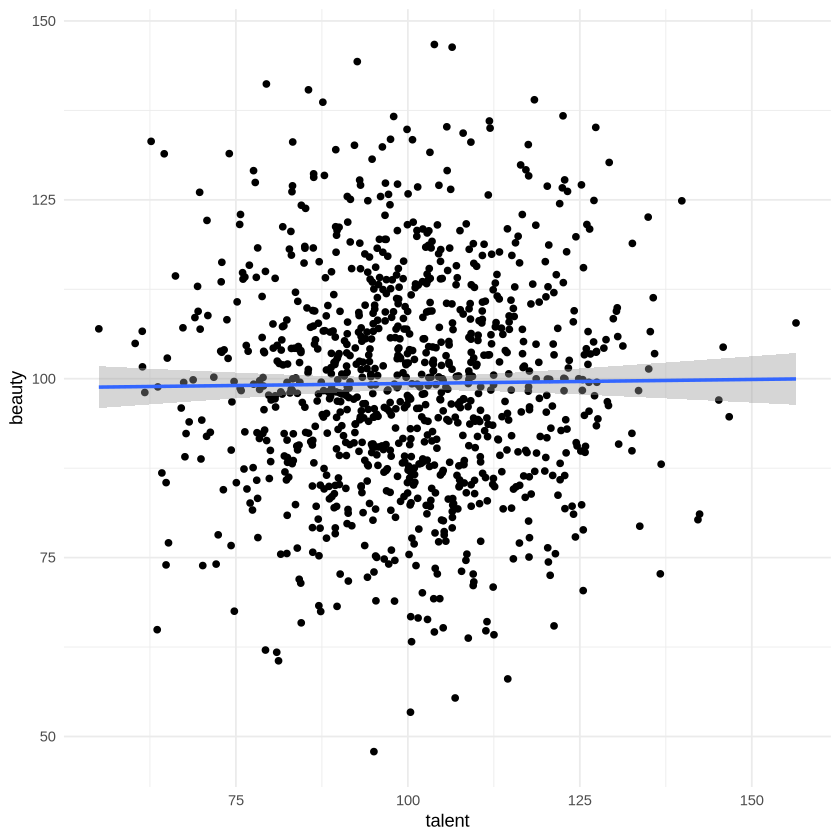

In [14]:
n <- 1000

bt <- tibble(
    talent = rnorm(n, mean = 100, sd = 15),
    beauty = rnorm(n, mean = 100, sd = 15)
)

bt |> ggplot(aes(x = talent, y = beauty)) +
    geom_point() +
    geom_smooth(method = "lm") +
    theme_minimal()

In [23]:
bt <- bt |> 
    mutate(
        isCelebrity = (talent + beauty >= 200)
    )

In [24]:
bts <- bt |> 
    filter(isCelebrity)

In [25]:
bt$isCelebrity |> table()


FALSE  TRUE 
  522   478 

`geom_smooth()` using formula = 'y ~ x'


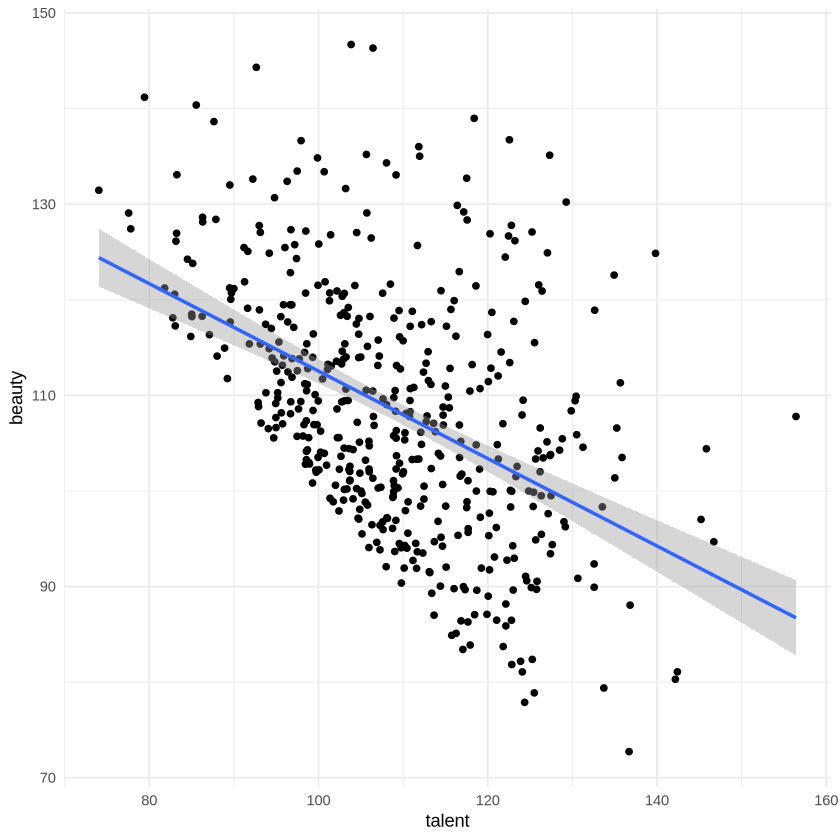

In [26]:
bts |>
    ggplot(aes(x = talent, y = beauty)) +
    geom_point() +
    geom_smooth(method = "lm") +
    theme_minimal()

In [27]:
lm(beauty ~ talent, data = bts) |> summary()


Call:
lm(formula = beauty ~ talent, data = bts)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.508  -8.543  -1.402   6.727  36.745 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 158.27078    4.50101   35.16   <2e-16 ***
talent       -0.45738    0.04093  -11.17   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.57 on 476 degrees of freedom
Multiple R-squared:  0.2078,	Adjusted R-squared:  0.2061 
F-statistic: 124.9 on 1 and 476 DF,  p-value: < 2.2e-16


In [29]:
lm(beauty ~ talent, data = bt) |> summary()


Call:
lm(formula = beauty ~ talent, data = bt)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.394 -10.215  -0.122   9.349  47.335 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 98.20708    3.18396  30.844   <2e-16 ***
talent       0.01126    0.03151   0.357    0.721    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.36 on 998 degrees of freedom
Multiple R-squared:  0.000128,	Adjusted R-squared:  -0.0008739 
F-statistic: 0.1278 on 1 and 998 DF,  p-value: 0.7208
